In [2]:
import pandas as pd
import numpy as np
import os
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.neighbors import KNeighborsClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, recall_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

In [3]:
# 统计每列中每个值的数量
def stat_label_count(
    df,
    freq,
    dataset_training_path,
    columns=[
        "top_or_bottom",
        "top_or_bottom_stat",
        "top_bottom_volatility_stat",
        "top_or_bottom_stat_optimized",
        "top_or_bottom_optimized",
        "top_bottom_volatility_optimized",
    ],
    version="0.1",
):
    result = {}
    for column in columns:
        result[column] = df[column].value_counts()

    # 将统计结果转换为 DataFrame
    result_df = pd.DataFrame(result).fillna(0).astype(int)

    # 保存统计结果为 CSV 文件
    result_df.to_csv(
        f"{dataset_training_path}label_value_counts_{freq}_{version}.csv", index_label="value"
    )

    print("统计结果已保存为 value_counts.csv")

In [1]:
# 文件路径
root_path_DEV = "C:/Users/HANJ29/Applications/btweb/stock_filestore/DEV/"
root_path_PROD = "C:/Users/HANJ29/Applications/btweb/stock_filestore/PROD/"
folder_ds_entry = "dataset_entry/"
# folder_ds_tech_funda = "dataset_tech_funda/"
dataset_training_path = root_path_DEV + "dataset_training/"
dataset_training_stat_path = root_path_DEV + "dataset_training/stat/"

dataset_entry_path = root_path_DEV + folder_ds_entry

In [4]:
freq = "W"
version = 0.1
df = pd.read_csv(f"{dataset_training_path}mapped_entry_{freq}.csv",)

In [5]:
stat_label_count(df, freq, dataset_training_stat_path)

统计结果已保存为 value_counts.csv


In [6]:
# 统计每个 ts_code 的空值数量
missing_counts = df['turnover_rate'].isna().groupby(df['ts_code_df1']).sum()

# 打印结果
print("每个 ts_code 的 turnover_rate 空值数量：")
print(missing_counts)
# 保存统计结果为 CSV 文件
missing_counts.to_csv(
    f"{dataset_training_stat_path}to_nan_value_counts_{freq}.csv", index_label="value"
)

每个 ts_code 的 turnover_rate 空值数量：
ts_code_df1
000001.SZ    0
000002.SZ    0
000004.SZ    0
000005.SZ    0
000006.SZ    0
            ..
873703.BJ    0
873706.BJ    0
873726.BJ    0
873806.BJ    0
873833.BJ    0
Name: turnover_rate, Length: 5410, dtype: int64


In [24]:
df.columns

Index(['ts_code_df1', 'trade_date', 'open', 'high', 'low', 'close_df1',
       'pre_close', 'change', 'pct_chg', 'vol', 'amount', 'atr', 'sl_atr',
       'sl_2atr', 'sl_3atr', 'sl_4atr', 'sl_5atr', 'pct_vol_chg',
       'pct_amount_chg', 'close_atr_diff', 'close_2atr_diff',
       'close_3atr_diff', 'close_4atr_diff', 'close_5atr_diff', 'pct_o2c',
       'lower_shadow', 'upper_shadow', 'dif', 'dea', 'bar', 'rsi_6', 'rsi_12',
       'rsi_24', 'k', 'd', 'j', 'mab_10', 'mab_25', 'mab_60', 'mab_120',
       'mab_200', 'turnover_rate', 'turnover_rate_f', 'volume_ratio', 'pe',
       'pe_ttm', 'pb', 'ps', 'ps_ttm', 'dv_ratio', 'dv_ttm', 'total_share',
       'float_share', 'free_share', 'total_mv', 'circ_mv', 'float_share_ratio',
       'free_share_ratio', 'top_or_bottom', 'top_or_bottom_stat',
       'top_bottom_volatility_stat', 'top_or_bottom_stat_optimized',
       'top_or_bottom_optimized', 'top_bottom_volatility_optimized'],
      dtype='object')

In [10]:
# 将 trade_date 转换为日期类型
df['trade_date'] = pd.to_datetime(df['trade_date'])

# 按 ts_code 分组，并对每组数据按照 trade_date 排序后，从第 200 行开始提取数据
result = df.groupby('ts_code_df1', group_keys=False).apply(lambda group: group.sort_values('trade_date').iloc[200:])

# 打印结果
result.describe()

C:\Users\HANJ29\AppData\Local\Temp\ipykernel_12596\3639114408.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df.groupby('ts_code_df1', group_keys=False).apply(lambda group: group.sort_values('trade_date').iloc[200:])


,trade_date,open,high,low,close_df1,pre_close,change,pct_chg,vol,amount,...,total_mv,circ_mv,float_share_ratio,free_share_ratio,top_or_bottom,top_or_bottom_stat,top_bottom_volatility_stat,top_or_bottom_stat_optimized,top_or_bottom_optimized,top_bottom_volatility_optimized
count,2272479,2.272479e+06,2.272479e+06,2.272479e+06,2.272479e+06,2.272479e+06,2.272479e+06,2.272479e+06,2.272479e+06,2.272479e+06,...,2.272478e+06,2.272478e+06,2.272478e+06,2.271067e+06,2.272479e+06,2.272479e+06,2.272479e+06,2.272479e+06,2.272479e+06,2.272479e+06
mean,2016-07-11 17:49:22.734704640,1.141450e+01,1.199340e+01,1.089139e+01,1.140889e+01,1.325104e+01,-1.842159e+00,-1.159297e+01,7.465526e+07,8.315883e+08,...,1.687734e+06,1.318338e+06,7.872255e-01,4.996919e-01,6.356301e-01,1.337016e-01,8.476382e-02,1.151549e-01,5.011853e-01,7.411070e-02
min,1994-11-04 00:00:00,1.400000e-01,1.400000e-01,9.000000e-02,1.100000e-01,1.600000e-01,-3.571015e+02,-9.573170e+01,5.000000e+02,2.790000e+03,...,2.543354e+03,2.073037e+03,1.273698e-02,4.060404e-04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2011-12-16 00:00:00,4.849300e+00,5.070000e+00,4.648900e+00,4.850000e+00,5.690000e+00,-1.733100e+00,-1.779000e+01,1.277658e+07,1.102388e+08,...,2.765113e+05,2.052753e+05,6.248960e-01,3.751776e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2018-03-02 00:00:00,7.694500e+00,8.065800e+00,7.354900e+00,7.691700e+00,8.950000e+00,-3.360000e-01,-4.090000e+00,3.171462e+07,2.965185e+08,...,5.101399e+05,4.054135e+05,8.794745e-01,5.009510e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2022-03-04 00:00:00,1.261200e+01,1.326150e+01,1.203000e+01,1.261000e+01,1.472000e+01,4.000000e-02,6.400000e-01,7.502460e+07,7.780331e+08,...,1.109968e+06,8.899588e+05,9.999692e-01,6.305300e-01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
max,2025-03-28 00:00:00,2.563742e+03,2.603268e+03,2.359294e+03,2.576640e+03,2.601000e+03,3.652800e+02,8.978430e+02,1.971536e+10,2.608253e+11,...,3.267370e+08,3.267370e+08,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00
std,NaN,2.445410e+01,2.538502e+01,2.357781e+01,2.446717e+01,2.584476e+01,5.434335e+00,2.068630e+01,1.772549e+08,2.075705e+09,...,7.500912e+06,5.770238e+06,2.439764e-01,1.790195e-01,8.084980e-01,4.524547e-01,3.649575e-01,4.227348e-01,7.643139e-01,3.427837e-01


In [11]:
# version = 0.1
# freq = 'd'
# df_test_d = pd.read_csv(f"{dataset_training_path}test_dataset_{freq}_{version}.csv",)

# 将 trade_date 列转换为日期类型
result['trade_date'] = pd.to_datetime(result['trade_date'])

# 删除 trade_date 大于 2025-03-05 的记录
result = result[result['trade_date'] <= pd.to_datetime('2025-03-05')]
result.describe()

,trade_date,open,high,low,close_df1,pre_close,change,pct_chg,vol,amount,...,total_mv,circ_mv,float_share_ratio,free_share_ratio,top_or_bottom,top_or_bottom_stat,top_bottom_volatility_stat,top_or_bottom_stat_optimized,top_or_bottom_optimized,top_bottom_volatility_optimized
count,2256177,2.256177e+06,2.256177e+06,2.256177e+06,2.256177e+06,2.256177e+06,2.256177e+06,2.256177e+06,2.256177e+06,2.256177e+06,...,2.256176e+06,2.256176e+06,2.256176e+06,2.254765e+06,2.256177e+06,2.256177e+06,2.256177e+06,2.256177e+06,2.256177e+06,2.256177e+06
mean,2016-06-18 19:58:17.733555968,1.136427e+01,1.194054e+01,1.084272e+01,1.135864e+01,1.321428e+01,-1.855638e+00,-1.167961e+01,7.422117e+07,8.258273e+08,...,1.684574e+06,1.314762e+06,7.862939e-01,4.993463e-01,6.402228e-01,1.346676e-01,8.537628e-02,1.159869e-01,5.048066e-01,7.464618e-02
min,1994-11-04 00:00:00,1.400000e-01,1.400000e-01,9.000000e-02,1.100000e-01,1.600000e-01,-3.571015e+02,-9.573170e+01,5.000000e+02,2.790000e+03,...,2.543354e+03,2.073037e+03,1.273698e-02,4.060404e-04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2011-11-25 00:00:00,4.840000e+00,5.060000e+00,4.640000e+00,4.840000e+00,5.690000e+00,-1.750700e+00,-1.807390e+01,1.270299e+07,1.093425e+08,...,2.759754e+05,2.044603e+05,6.227499e-01,3.749571e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2018-02-02 00:00:00,7.680000e+00,8.050000e+00,7.340000e+00,7.679100e+00,8.930000e+00,-3.400000e-01,-4.140800e+00,3.152540e+07,2.942429e+08,...,5.092816e+05,4.042430e+05,8.776135e-01,5.005612e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2022-02-11 00:00:00,1.257130e+01,1.321650e+01,1.199400e+01,1.256900e+01,1.469000e+01,4.000000e-02,6.122000e-01,7.456541e+07,7.722676e+08,...,1.107753e+06,8.873265e+05,9.999652e-01,6.300704e-01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
max,2025-02-28 00:00:00,2.563742e+03,2.603268e+03,2.359294e+03,2.576640e+03,2.601000e+03,3.652800e+02,8.978430e+02,1.971536e+10,2.608253e+11,...,3.267370e+08,3.267370e+08,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00
std,NaN,2.433653e+01,2.526233e+01,2.346540e+01,2.434963e+01,2.574721e+01,5.448277e+00,2.072830e+01,1.767650e+08,2.067852e+09,...,7.486588e+06,5.758728e+06,2.443562e-01,1.790202e-01,8.095997e-01,4.539431e-01,3.662023e-01,4.241455e-01,7.658777e-01,3.439617e-01


In [12]:
def check_nan_impact_on_labels(df, columns_to_check, label_columns):
    # 初始化一个字典来存储结果
    results = []

    for column in columns_to_check:
        # 筛选出指定列为空值的行
        nan_rows = df[df[column].isnull()]

        for label_column in label_columns:
            # 统计标签列中每个值的数量
            value_counts = nan_rows[label_column].value_counts()
            for value, count in value_counts.items():
                results.append({
                    'column_with_nan': column,
                    'label_column': label_column,
                    'label_value': value,
                    'count': count
                })

    return pd.DataFrame(results)

In [13]:
# 要检查的列
columns_to_check = [
    "change",
    "pct_chg",
    "vol",
    "atr",
    "pct_vol_chg",
    "pct_o2c",
    "lower_shadow",
    "upper_shadow",
    "dif",
    "dea",
    "bar",
    "rsi_6",
    "rsi_12",
    "rsi_24",
    "k",
    "d",
    "j",
    "turnover_rate",
    "turnover_rate_f",
    "volume_ratio",
    "pe",
    "pe_ttm",  # 当为负值时得到的数据为NaN
    "pb",
    "ps",
    "ps_ttm",
    "dv_ratio",
    # "dv_ttm",
    "total_share",
    "float_share",
    "free_share",
    "total_mv",
    "circ_mv",
    # "float_share_ratio",
    "free_share_ratio",
    "mab_10",
    "mab_25",
    "mab_60",
    "mab_120",
    "mab_200",
]

# 标签列
label_columns = [
    "top_or_bottom",
    "top_or_bottom_stat",
    "top_bottom_volatility_stat",
    "top_or_bottom_stat_optimized",
    "top_or_bottom_optimized",
    "top_bottom_volatility_optimized",
]

In [14]:
# 统计空值对标签列的影响
# freq = "D"
version = "0.1"
# 读取数据
nan_impact = check_nan_impact_on_labels(result, columns_to_check, label_columns)
# 保存结果到 CSV 文件
nan_impact.to_csv(f"{dataset_training_stat_path}nan_impact_{freq}_{version}.csv", index=False)
print(nan_impact)

      column_with_nan                     label_column  label_value   count
0                  pe                    top_or_bottom            0  181637
1                  pe                    top_or_bottom            2   67013
2                  pe                    top_or_bottom            1   65922
3                  pe               top_or_bottom_stat            0  286393
4                  pe               top_or_bottom_stat            1   14798
..                ...                              ...          ...     ...
157  free_share_ratio          top_or_bottom_optimized            2     242
158  free_share_ratio          top_or_bottom_optimized            1     230
159  free_share_ratio  top_bottom_volatility_optimized            0    1317
160  free_share_ratio  top_bottom_volatility_optimized            1      64
161  free_share_ratio  top_bottom_volatility_optimized            2      31

[162 rows x 4 columns]


In [17]:
stat_label_count(result, freq, dataset_training_stat_path, version=0.2)

统计结果已保存为 value_counts.csv


In [ ]:
result["dv_ratio"] = result["dv_ratio"].fillna(0)
result["dv_ttm"] = result["dv_ttm"].fillna(0)
# result.drop(columns=["close", "float_mv"], inplace=True)
stat_label_count(result, freq, dataset_training_stat_path, version=0.3)

统计结果已保存为 value_counts.csv


In [19]:
# 删除 'turnover_rate' 和 'volume_ratio' 列中包含空值的行
nan_columns = [
    "pb",
    "ps",
    "ps_ttm",
    "free_share",
    "total_share",
    "float_share",
    "free_share",
    "total_mv",
    "circ_mv",
    "free_share_ratio",
]
result = result.dropna(subset=nan_columns)

In [20]:
version = "0.2"
# 读取数据
nan_impact = check_nan_impact_on_labels(result, columns_to_check, label_columns)
# 保存结果到 CSV 文件
nan_impact.to_csv(f"{dataset_training_stat_path}nan_impact_{freq}_{version}.csv", index=False)
print(nan_impact)

   column_with_nan                     label_column  label_value   count
0               pe                    top_or_bottom            0  169520
1               pe                    top_or_bottom            2   62774
2               pe                    top_or_bottom            1   61738
3               pe               top_or_bottom_stat            0  267689
4               pe               top_or_bottom_stat            1   13779
5               pe               top_or_bottom_stat            2   12564
6               pe       top_bottom_volatility_stat            0  276285
7               pe       top_bottom_volatility_stat            1    9610
8               pe       top_bottom_volatility_stat            2    8137
9               pe     top_or_bottom_stat_optimized            0  271289
10              pe     top_or_bottom_stat_optimized            1   11874
11              pe     top_or_bottom_stat_optimized            2   10869
12              pe          top_or_bottom_optimized

In [21]:
stat_label_count(result, freq, dataset_training_stat_path, version=0.4)

统计结果已保存为 value_counts.csv


In [22]:
result.to_csv(f"{dataset_training_path}mapped_entry_{freq}_cleaned.csv", index=False)

In [23]:
del result

In [7]:
freq = "M"
version = 0.2
df_m = pd.read_csv(f"{dataset_training_path}mapped_entry_{freq}.csv",)

In [8]:
from sklearn.preprocessing import RobustScaler


# 初始化 RobustScaler
scaler = RobustScaler()

# 指定需要归一化的列
columns_to_scale = ['pct_chg', 'pct_vol_chg']

# 对指定列进行归一化
df_m[columns_to_scale] = scaler.fit_transform(df_m[columns_to_scale])

# 打印结果
print("归一化后的数据：")
df_m

归一化后的数据：


,ts_code_df1,trade_date,open,high,low,close_df1,pre_close,change,pct_chg,vol,...,total_mv,circ_mv,float_share_ratio,free_share_ratio,top_or_bottom,top_or_bottom_stat,top_bottom_volatility_stat,top_or_bottom_stat_optimized,top_or_bottom_optimized,top_bottom_volatility_optimized
0,000001.SZ,1991-07-31,1.95,1.95,1.71,1.71,1.96,-0.25,-0.830531,5800.0,...,143269.5051,78281.0000,0.546390,0.546390,0,0,0,0,0,0
1,000001.SZ,1991-08-30,3.15,3.15,1.53,1.61,3.16,-1.55,-3.271015,2757300.0,...,72992.7574,39882.5000,0.546390,0.546390,2,0,0,0,2,0
2,000001.SZ,1991-09-30,1.61,1.61,1.45,1.55,1.61,-0.06,-0.223268,6213700.0,...,70325.2480,38425.0000,0.546390,0.546390,1,1,1,1,1,1
3,000001.SZ,1991-10-31,1.57,2.98,1.57,2.88,1.56,1.32,5.718225,9587900.0,...,130465.4600,71285.0000,0.546390,0.546390,0,0,0,0,0,0
4,000001.SZ,1991-11-29,2.83,3.89,2.83,2.91,2.81,0.10,0.266980,10683600.0,...,135072.9762,73802.5000,0.546390,0.546390,2,0,0,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
778848,873833.BJ,2024-10-31,12.00,15.88,8.53,12.94,9.71,3.23,2.264291,96491816.0,...,106573.8400,41055.1702,0.385227,0.308795,0,0,0,0,0,0
778849,873833.BJ,2024-11-29,12.98,19.50,11.75,17.31,12.94,4.37,2.298588,117737350.0,...,142565.1600,54920.0152,0.385227,0.308795,2,2,2,2,2,2
778850,873833.BJ,2024-12-31,17.13,19.26,11.24,11.40,17.31,-5.91,-2.268325,65323233.0,...,93890.4000,36169.1608,0.385227,0.308795,0,0,0,0,0,0
778851,873833.BJ,2025-01-27,11.38,12.57,10.71,11.20,11.40,-0.20,-0.090114,22950780.0,...,92243.2000,35534.6141,0.385227,0.308795,1,0,0,0,1,0


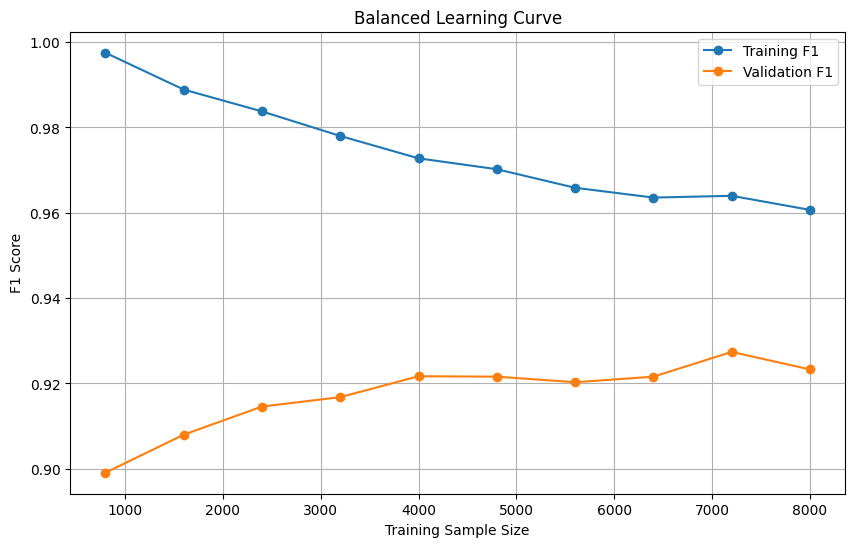

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve

# 生成模拟数据（可替换为真实股票数据）
X, y = make_classification(n_samples=10000, n_features=20, n_informative=15, n_redundant=5, random_state=42)

# 初始化模型并调参
rf = RandomForestClassifier(n_estimators=100, max_depth=8, class_weight='balanced')

# 生成学习曲线
train_sizes, train_scores, val_scores = learning_curve(
    estimator=rf,
    X=X,
    y=y,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1_macro'
)

# 绘制曲线
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Training F1')
plt.plot(train_sizes, np.mean(val_scores, axis=1), 'o-', label='Validation F1')
plt.xlabel('Training Sample Size')
plt.ylabel('F1 Score')
plt.title('Balanced Learning Curve')
plt.legend()
plt.grid(True)
plt.show()